In [2]:
%load_ext autoreload
%autoreload 2

import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
from datetime import datetime
from order_fingers import TouchTracker
import matplotlib.pyplot as plt
import warnings
import itertools
from itertools import combinations
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

np.random.seed(42)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
DB_PATH = "./labeled_new.sqlite"

SENSOR_COLUMNS = [
    'button_pressed',
    'motor_angle',
    'touch_1_position', 'touch_1_pressure', 'touch_1_channel',
    'touch_2_position', 'touch_2_pressure', 'touch_2_channel',
    'touch_3_position', 'touch_3_pressure', 'touch_3_channel',
    'touch_4_position', 'touch_4_pressure', 'touch_4_channel',
    'touch_5_position', 'touch_5_pressure', 'touch_5_channel',
]
TIMESTAMP_COLUMN = 'timestamp_ms'
ID_COLUMNS = ['participant_id', 'session_task_id']
LABEL_COLUMN = 'parent_gesture'

WINDOW_SIZE_SAMPLES = 60
WINDOW_STRIDE_SAMPLES = 20
SAMPLING_RATE_HZ = 70  # in Hz
TOUCH_MOVE_THRESHOLD = 0.01  # Radians
WINDOW_GESTURE_MAJORITY_THRESHOLD = 0.4  # 40%

In [17]:
query = """
WITH start_end_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        MIN(e.sensor_data_index) AS next_end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    WHERE s.marker_type = 'start'
      AND e.marker_type = 'end'
    GROUP BY s.session_task_id, s.sensor_data_index
),
start_marker_timestamps AS (
    SELECT
        sensorData.session_task_id,
        session_task_row_index,
        preciseMarker.id AS group_id
    FROM sensorData
    JOIN preciseMarker
        ON sensorData.session_task_id = preciseMarker.session_task_id
       AND session_task_row_index = preciseMarker.sensor_data_index
    WHERE preciseMarker.marker_type = 'start'
),
session_first_start_last_end AS (
    SELECT
        sei.session_task_id,
        MIN(sei.start_index) AS first_start_index,
        MAX(sei.next_end_index) AS last_end_index
    FROM start_end_indices sei
    GROUP BY sei.session_task_id
),
gesture_samples AS (
    SELECT 
        sd.id,
        sd.session_task_id,
        sd.session_task_row_index,
        sd.timestamp,
        sd.timestamp_ms,
        sd.button_pressed,
        sd.motor_angle,
        sd.touch_1_position,
        sd.touch_1_pressure,
        sd.touch_1_channel,
        sd.touch_2_position,
        sd.touch_2_pressure,
        sd.touch_2_channel,
        sd.touch_3_position,
        sd.touch_3_pressure,
        sd.touch_3_channel,
        sd.touch_4_position,
        sd.touch_4_pressure,
        sd.touch_4_channel,
        sd.touch_5_position,
        sd.touch_5_pressure,
        sd.touch_5_channel,
        rt.title AS gesture,
        CASE WHEN smt.group_id is not null THEN rtParent.title ELSE 'No Gesture' END AS parent_gesture,
        s.participant_id,
        CASE WHEN smt.group_id is not null THEN 1 ELSE 0 END AS is_gesture,
        smt.group_id
    FROM sensorData sd
    left JOIN start_end_indices sei
      ON sd.session_task_id = sei.session_task_id
     AND sd.session_task_row_index BETWEEN sei.start_index AND sei.next_end_index
    left JOIN start_marker_timestamps smt
      ON smt.session_task_id = sei.session_task_id
     AND smt.session_task_row_index = sei.start_index
     JOIN session_first_start_last_end sfsle
      ON sd.session_task_id = sfsle.session_task_id
        AND sd.session_task_row_index BETWEEN sfsle.first_start_index AND sfsle.last_end_index
    LEFT JOIN sessionTask st
      ON sd.session_task_id = st.id
    LEFT JOIN session s
      ON st.session_id = s.id
    LEFT JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    LEFT JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    WHERE rtParent.title != 'Szenarien'
)

-- Final combined dataset
SELECT * FROM gesture_samples
WHERE is_gesture = 1
ORDER BY session_task_id, session_task_row_index;
"""

with sqlite3.connect(DB_PATH) as conn:
    df_raw = pd.read_sql_query(query, conn)

In [18]:
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
df_raw['time_diff'] = df_raw.groupby(['session_task_id', 'timestamp']).cumcount()
df_raw['recordings_per_second'] = df_raw.groupby(['session_task_id', 'timestamp'])['id'].transform('count')
df_raw['estimated_timestamp'] = df_raw['timestamp'] + pd.to_timedelta(df_raw['time_diff'] / df_raw['recordings_per_second'], unit='s')
df_raw = df_raw.drop(columns=['time_diff', 'recordings_per_second'])

df_raw["timestamp_ms"] = (df_raw["estimated_timestamp"].astype(np.int64) // 10**6).astype(np.int64)

In [19]:
df_raw["gesture"] = df_raw["gesture"].astype("category")
df_raw["parent_gesture"] = df_raw["parent_gesture"].astype("category")

In [20]:
# Normalize the input data
# 1. Normalize all positions from [0, 2PI] to [0, 1]
for col in SENSOR_COLUMNS:
    if 'position' in col:
        df_raw[col] = df_raw[col] / (2 * np.pi)
# 2. Normalize pressures using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'pressure' in col:
        df_raw[col] = df_raw.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 3. Normalize channel values using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'channel' in col:
        df_raw[col] = df_raw.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 4. Normalize motor_angle using min max scaling to [0, 1], per participant
df_raw['motor_angle'] = df_raw.groupby('participant_id')['motor_angle'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)       

In [21]:
df_raw[LABEL_COLUMN].value_counts()

parent_gesture
No Gesture                        25966
Pinch Swipe                       12037
Tap and Hold                      11985
Spread Swipe                       9049
Single Swipe                       6072
Two-Finger Opposite Double Tap     3010
Two-Finger Double Tap              3001
Double Tap                         2784
Two-Finger Opposite Tap            1719
Two-Finger Tap                     1646
Single Tap                         1407
Name: count, dtype: int64

In [22]:
# Sort after ID_COLUMNS and TIMESTAMP_COLUMN
df_raw = df_raw.sort_values(by=ID_COLUMNS + [TIMESTAMP_COLUMN]).reset_index(drop=True)

In [23]:
import pandas as pd
import numpy as np

TOUCH_COLUMNS_BASE = ['position', 'pressure', 'channel']
MAX_TOUCHES = 5
TOUCH_PREFIXES = [f'touch_{i+1}' for i in range(MAX_TOUCHES)]

def process_and_stabilize_touches(df: pd.DataFrame):
    all_stabilized_rows = []
    active_ids_per_row = []
    
    tracker = TouchTracker() 
    tracker_group_id = None
    
    # id_to_slot_map: {touch_id: slot_index}
    id_to_slot_map = {} 
    # last_seen_in_row: {touch_id: index_of_last_appearance}
    last_seen_in_row = {} 

    for index, row in df.iterrows():
        current_group_id = row.get('session_task_id', None)
        
        if tracker_group_id != current_group_id:
            tracker.clear()
            id_to_slot_map = {}
            last_seen_in_row = {}
            tracker_group_id = current_group_id
        
        # 1. Extract raw touches
        new_touches = []
        for prefix in TOUCH_PREFIXES:
            pos = row[f'{prefix}_position']
            press = row[f'{prefix}_pressure']
            chan = row[f'{prefix}_channel']
            new_touches.append((pos, press, chan))
            
        # 2. Assign IDs via tracker
        matched_touches = tracker.assign_ids(new_touches)
        
        # 3. Handle Slot Mapping with Eviction Logic
        row_slots = [np.nan] * (MAX_TOUCHES * len(TOUCH_COLUMNS_BASE))
        current_row_ids = [t[0] for t in matched_touches]

        for touch in matched_touches:
            tid, touch_data = touch[0], touch[1:]
            last_seen_in_row[tid] = index # Track when we last saw this ID active

            if tid not in id_to_slot_map:
                existing_slots = set(id_to_slot_map.values())
                
                if len(existing_slots) < MAX_TOUCHES:
                    # Case A: Room available, find first empty slot
                    for s_idx in range(MAX_TOUCHES):
                        if s_idx not in existing_slots:
                            id_to_slot_map[tid] = s_idx
                            break
                else:
                    # Case B: Map is full. Find the ID in the map that 
                    # hasn't been seen for the longest time and steal its slot.
                    # This happens if persistence is holding a slot for a finger that isn't there.
                    oldest_tid = min(id_to_slot_map.keys(), key=lambda x: last_seen_in_row.get(x, -1))
                    stolen_slot = id_to_slot_map.pop(oldest_tid)
                    id_to_slot_map[tid] = stolen_slot
                    # Also clean up tracker if we are force-evicting from slot map
                    if oldest_tid in tracker.persistence_buffer:
                        del tracker.persistence_buffer[oldest_tid]
            
            slot = id_to_slot_map[tid]
            start_idx = slot * len(TOUCH_COLUMNS_BASE)
            row_slots[start_idx : start_idx + 3] = touch_data

        # 4. Standard Cleanup: Sync with Tracker's own expiration
        all_remembered_ids = set(tracker.active_touches.keys()) | set(tracker.persistence_buffer.keys())
        ids_to_forget = [tid for tid in id_to_slot_map if tid not in all_remembered_ids]
        for tid in ids_to_forget:
            id_to_slot_map.pop(tid, None)

        all_stabilized_rows.append(row_slots)
        active_ids_per_row.append(current_row_ids)

    # DataFrame creation...
    new_col_names = [f'{p}_{c}' for p in TOUCH_PREFIXES for c in TOUCH_COLUMNS_BASE]
    stabilized_df = pd.DataFrame(all_stabilized_rows, index=df.index, columns=new_col_names)
    stabilized_df['active_ids'] = active_ids_per_row
    return stabilized_df

In [24]:
# Stabilize dataframe, but only the first session_task_id for testing
stabilized_touch_data = process_and_stabilize_touches(df_raw.copy())
non_touch_cols = [c for c in df_raw.columns if not any(c.startswith(f'touch_{i+1}') for i in range(MAX_TOUCHES))]
final_df = df_raw[non_touch_cols].copy()

df_clean = final_df.join(stabilized_touch_data)

print("Stabilization Complete.")

Stabilization Complete.


In [25]:
# Print unique parent gestures
print("Unique Parent Gestures:")
print(df_clean[LABEL_COLUMN].unique())

Unique Parent Gestures:
['Two-Finger Tap', 'Two-Finger Opposite Double Tap', 'Two-Finger Opposite Tap', 'No Gesture', 'Double Tap', ..., 'Two-Finger Double Tap', 'Single Tap', 'Spread Swipe', 'Single Swipe', 'Pinch Swipe']
Length: 11
Categories (11, object): ['Double Tap', 'No Gesture', 'Pinch Swipe', 'Single Swipe', ..., 'Two-Finger Double Tap', 'Two-Finger Opposite Double Tap', 'Two-Finger Opposite Tap', 'Two-Finger Tap']


In [61]:
# Create a new column of gesture_group, where Tap=(parent_gesture matches '% Tap'), Swipe=(parent_gesture matches '% Swipe'), Long=(parent_gesture=Tap and Hold), No Gesture=No Gesture, else Other
def categorize_gesture(gesture):
    if gesture.endswith(' Tap'):
        return 'Tap'
    elif 'Swipe' in gesture:
        return 'Swipe'
    elif gesture == 'Tap and Hold':
        return 'Long'
    elif gesture == 'No Gesture':
        return 'No Gesture'
    else:
        return 'Other'
df_clean['gesture_group'] = df_clean[LABEL_COLUMN].apply(categorize_gesture).astype('category')

In [62]:
# Print the counts of each gesture group
print("\nGesture Group Counts:")
print(df_clean['gesture_group'].value_counts())


Gesture Group Counts:
gesture_group
Swipe         27158
No Gesture    25966
Tap           13567
Long          11985
Name: count, dtype: int64


In [67]:
# Describe the dataset per gesture group, excluding session_task_row_index, timestamp, timestamp_ms, estimated_timestamp, active_ids
description_cols = [col for col in df_clean.columns if col not in ['session_task_row_index', 'timestamp', 'timestamp_ms', 'estimated_timestamp', 'active_ids']]
print("\nDataset Description by Gesture Group:")
df_clean.groupby('gesture_group')[description_cols].describe()


Dataset Description by Gesture Group:


button_pressed                                               \
                       count      mean       std  min  25%  50%  75%  max   
gesture_group                                                               
Long                 11985.0  0.000000  0.000000  0.0  0.0  0.0  0.0  0.0   
No Gesture           25966.0  0.059193  0.235990  0.0  0.0  0.0  0.0  1.0   
Swipe                27158.0  0.000221  0.014862  0.0  0.0  0.0  0.0  1.0   
Tap                  13567.0  0.000000  0.000000  0.0  0.0  0.0  0.0  0.0   

              motor_angle                                                    \
                    count      mean       std       min       25%       50%   
gesture_group                                                                 
Long              11985.0  0.416078  0.448315  0.000103  0.005189  0.019403   
No Gesture        25966.0  0.755714  0.269401  0.001610  0.522023  0.882023   
Swipe             27158.0  0.442461  0.475166  0.000000  0.001382  0.031017   
Tap               13567.0  0.441728  0.463885  0.000041  0.001994  0.020817   

                                  is_gesture                                \
                    75%       max      count mean  std  min  25%  50%  75%   
gesture_group                                                                
Long           0.992549  0.999597    11985.0  1.0  0.0  1.0  1.0  1.0  1.0   
No Gesture     0.991816  1.000000    25966.0  1.0  0.0  1.0  1.0  1.0  1.0   
Swipe          0.998056  1.000000    27158.0  1.0  0.0  1.0  1.0  1.0  1.0   
Tap            0.992123  1.000000    13567.0  1.0  0.0  1.0  1.0  1.0  1.0   

                   touch_1_position                                          \
               max            count      mean       std       min       25%   
gesture_group                                                                 
Long           1.0          11573.0  0.395828  0.258820  0.002474  0.128424   
No Gesture     1.0          16359.0  0.498916  0.280755  0.000333  0.260248   
Swipe          1.0          20021.0  0.402623  0.261667  0.000272  0.161617   
Tap            1.0          12379.0  0.362407  0.244019  0.005190  0.143143   

                                            touch_1_pressure            \
                    50%       75%       max            count      mean   
gesture_group                                                            
Long           0.439886  0.622587  0.897865          11573.0  0.580388   
No Gesture     0.484878  0.727684  0.999433          16359.0  0.457886   
Swipe          0.385620  0.569250  0.999366          20021.0  0.299210   
Tap            0.296491  0.550338  0.998986          12379.0  0.476428   

                                                                           \
                    std       min       25%       50%       75%       max   
gesture_group                                                               
Long           0.119394  0.118256  0.521501  0.571840  0.652297  0.951499   
No Gesture     0.219877  0.000000  0.278134  0.480778  0.607894  1.000000   
Swipe          0.195276  0.000000  0.158892  0.267728  0.388339  1.000000   
Tap            0.179777  0.000450  0.379275  0.491287  0.568272  0.981441   

              touch_1_channel                                          \
                        count      mean       std  min       25%  50%   
gesture_group                                                           
Long                  11573.0  0.548345  0.136042  0.2  0.444444  0.5   
No Gesture            16359.0  0.510365  0.184395  0.0  0.400000  0.5   
Swipe                 20021.0  0.395434  0.190131  0.0  0.250000  0.4   
Tap                   12379.0  0.448474  0.166884  0.0  0.333333  0.4   

                             touch_2_position                                \
                    75%  max            count      mean       std       min   
gesture_group                                                                 
Long       

In [76]:
# Add new features to the dataframe, for improved modeling
def create_feature_df(df_clean, smoothing_window=5, long_smoothing_window=20):
    # Create empty feature dataframe
    feature_df = df_clean.copy()
    additional_features = []

    def add_feature(name, values):
        feature_df[name] = values
        additional_features.append(name)

    # Distances between each finger (including wrapping)
    def short_dist(a, b):
        return np.abs(np.arctan2(np.sin(a - b), np.cos(a - b)))
    
    # Instant Features
    pressure_cols = [f"touch_{i+1}_pressure" for i in range(5)]
    active_touches = (feature_df[pressure_cols] > 0)
    add_feature("num_active_touches", active_touches.sum(axis=1))

    # Distances for each finger in the rolling window to each other finger
    for (i, j) in combinations(range(1, 6), 2):
        pos_i = feature_df[f'touch_{i}_position']
        pos_j = feature_df[f'touch_{j}_position']
        p_i = feature_df[f"touch_{i}_pressure"]
        p_j = feature_df[f"touch_{j}_pressure"]

        # distance only when both fingers are active; else 0 (or np.nan if you prefer)
        dist_col = f"dist_{i}_{j}"
        dist = short_dist(pos_i, pos_j)
        both_touching = (p_i > 0) & (p_j > 0)
        # add_feature(dist_col, dist)
        # Add min and max dist over long window
        long_min_dist = dist.rolling(window=long_smoothing_window, min_periods=1).min()
        long_max_dist = dist.rolling(window=long_smoothing_window, min_periods=1).max()
        # add_feature(f"{dist_col}_long_min", long_min_dist)
        # add_feature(f"{dist_col}_long_max", long_max_dist)
        # add_feature(f"{dist_col}_both_touching", both_touching.astype(int))

        # Calculate distance velocity
        dist_diff = dist.diff().fillna(0)
        time_diff = feature_df[TIMESTAMP_COLUMN].diff().fillna(1) / 1000.0  # convert ms to s
        dist_velocity = dist_diff / time_diff
        # add_feature(f"{dist_col}_velocity", dist_velocity)

        # Calculate a flag if both fingers are active in the long smoothing window
        # long_both_touching = both_touching.rolling(window=long_smoothing_window, min_periods=1).min() > 0
        # add_feature(f"{dist_col}_long_both_active", long_both_touching.astype(int))

        # Calculate a flag if both have moved
        # min_long_rolling_i = pos_i.rolling(window=long_smoothing_window, min_periods=1).min()
        # max_long_rolling_i = pos_i.rolling(window=long_smoothing_window, min_periods=1).max()
        # has_moved_i = (max_long_rolling_i - min_long_rolling_i) > TOUCH_MOVE_THRESHOLD
        # min_long_rolling_j = pos_j.rolling(window=long_smoothing_window, min_periods=1).min()
        # max_long_rolling_j = pos_j.rolling(window=long_smoothing_window, min_periods=1).max()
        # has_moved_j = (max_long_rolling_j - min_long_rolling_j) > TOUCH_MOVE_THRESHOLD
        # both_moved = has_moved_i & has_moved_j
        # add_feature(f"{dist_col}_both_moved_longterm", both_moved.astype(int))

    # Smoothed Features
    for touch_num in range(1, 6):
        position_col = f'touch_{touch_num}_position'
        pressure_col = f'touch_{touch_num}_pressure'
        channel_col = f'touch_{touch_num}_channel'

        # velocity calculation
        pos_diff = feature_df[position_col].diff().fillna(0)
        time_diff = feature_df[TIMESTAMP_COLUMN].diff().fillna(1) / 1000.0  # convert ms to s
        velocity = pos_diff / time_diff
        add_feature(f'touch_{touch_num}_position_velocity', velocity.rolling(window=smoothing_window, min_periods=1).mean())

        # split to rotational position into x and y components for smoothing
        # add_feature(f'touch_{touch_num}_pos_x', np.cos(2 * np.pi * feature_df[position_col]))
        # add_feature(f'touch_{touch_num}_pos_y', np.sin(2 * np.pi * feature_df[position_col]))

        # Get the min and max distance to all other fingers
        other_positions = [f'touch_{i}_position' for i in range(1, 6) if i != touch_num]
        if other_positions:
            for other_pos_col in other_positions:
                dist_to_other = short_dist(feature_df[position_col], feature_df[other_pos_col])
                add_feature(f'touch_{touch_num}_dist_to_{other_pos_col}', dist_to_other)
                # Calculate velocity of distance to other finger
                dist_diff = dist_to_other.diff().fillna(0)
                dist_velocity = dist_diff / time_diff
                # add_feature(f'touch_{touch_num}_dist_to_{other_pos_col}_velocity', dist_velocity)

        is_touching = (feature_df[pressure_col] > 0)
        # add_feature(f'touch_{touch_num}_is_active', is_touching.astype(int))
        is_active_smoothed = is_touching.rolling(window=smoothing_window, min_periods=1).mean()
        # add_feature(f'touch_{touch_num}_is_active_smoothed', is_active_smoothed)

        # Add a flag, whether a finger touched and released and touched again in the smoothing window
        reactivation = (~is_touching.shift(1, fill_value=False)) & is_touching
        touch_before = is_touching.rolling(smoothing_window).max().astype(bool)
        reactivation_in_window = reactivation.rolling(smoothing_window).max().astype(bool)
        has_reactivated = (touch_before & reactivation_in_window)
        # add_feature(f'touch_{touch_num}_has_reactivated', has_reactivated.astype(int))

        min_long_rolling_pos = feature_df[position_col].rolling(window=long_smoothing_window, min_periods=1).min()
        max_long_rolling_pos = feature_df[position_col].rolling(window=long_smoothing_window, min_periods=1).max()
        has_moved = (max_long_rolling_pos - min_long_rolling_pos) > TOUCH_MOVE_THRESHOLD
        # add_feature(f'touch_{touch_num}_has_moved_longterm', has_moved.astype(int))

        long_touch = is_touching.rolling(window=long_smoothing_window, min_periods=1).min() > 0
        # add_feature(f'touch_{touch_num}_long_touch', long_touch.astype(int))

        # Add flag if the touch is active or not, it is active if np.any(is_touching) and (has_moved or not is_continuous_touch)
        is_active_touch = is_touching & (has_moved | (~long_touch))
        add_feature(f'touch_{touch_num}_is_active_touch', is_active_touch.astype(int))

        add_feature(f'{position_col}_mean', feature_df[position_col].rolling(window=smoothing_window, min_periods=1).mean())
        add_feature(f'{pressure_col}_mean', feature_df[pressure_col].rolling(window=smoothing_window, min_periods=1).mean())
        add_feature(f'{channel_col}_mean', feature_df[channel_col].rolling(window=smoothing_window, min_periods=1).mean())
        
        add_feature(f'{position_col}_diff', feature_df[position_col].diff().fillna(0))
        add_feature(f'{pressure_col}_diff', feature_df[pressure_col].diff().fillna(0))
        add_feature(f'{channel_col}_diff', feature_df[channel_col].diff().fillna(0))
        
        add_feature(f'{position_col}_rollstd', feature_df[position_col].rolling(window=smoothing_window, min_periods=1).std().fillna(0))
        add_feature(f'{pressure_col}_rollstd', feature_df[pressure_col].rolling(window=smoothing_window, min_periods=1).std().fillna(0))
        add_feature(f'{channel_col}_rollstd', feature_df[channel_col].rolling(window=smoothing_window, min_periods=1).std().fillna(0))

    # add_feature("num_active_touches_mean", feature_df["num_active_touches"]
            # .rolling(window=smoothing_window, min_periods=1)
            # .mean())
    # add_feature("num_active_touches_max", feature_df["num_active_touches"]
            # .rolling(window=smoothing_window, min_periods=1)
            # .max())
    # active_touches_contrast = active_touches - active_touches.rolling(window=2, min_periods=1).median()
    # add_feature("num_active_touches_contrast", active_touches_contrast.sum(axis=1))
    
    dist_cols = [c for c in feature_df.columns if c.startswith("dist_")]
    for col in dist_cols:
        add_feature(f"{col}_rollmean", feature_df[col]
            .rolling(window=smoothing_window, min_periods=1)
            .mean())
        add_feature(f"{col}_rollstd", feature_df[col]
            .rolling(window=smoothing_window, min_periods=1)
            .std()
            .fillna(0.0))
        
    vel_cols = [c for c in feature_df.columns if c.endswith("_velocity")]
    for col in vel_cols:
        add_feature(f"{col}_rollmean", feature_df[col]
            .rolling(window=smoothing_window, min_periods=1)
            .mean())
        add_feature(f"{col}_rollstd", feature_df[col]
            .rolling(window=smoothing_window, min_periods=1)
            .std()
            .fillna(0.0))

    return feature_df, additional_features

In [77]:
feature_df, additional_features = create_feature_df(df_clean.copy(), smoothing_window=5, long_smoothing_window=20)

In [78]:
# Describe, per gesture group, the added features
print("\nAdded Feature Description by Gesture Group:")
feature_df.groupby('gesture_group')[additional_features].describe()


Added Feature Description by Gesture Group:


num_active_touches                                               \
                           count      mean       std  min  25%  50%  75%  max   
gesture_group                                                                   
Long                     11985.0  2.385565  0.606574  0.0  2.0  2.0  3.0  3.0   
No Gesture               25966.0  2.163329  1.533958  0.0  1.0  2.0  3.0  5.0   
Swipe                    27158.0  1.826239  0.686243  0.0  2.0  2.0  2.0  4.0   
Tap                      13567.0  2.450063  1.120813  0.0  2.0  3.0  3.0  4.0   

              touch_1_position_velocity                                \
                                  count      mean       std       min   
gesture_group                                                           
Long                            11985.0  0.000052  0.006407 -0.083027   
No Gesture                      25966.0 -0.015384  0.228650 -5.158865   
Swipe                           27158.0 -0.015388  0.139292 -1.230201   
Tap                             13567.0 -0.000386  0.006949 -0.100776   

                                                       \
                    25%       50%       75%       max   
gesture_group                                           
Long          -0.001117  0.000000  0.001314  0.098594   
No Gesture    -0.003297  0.000000  0.000642  8.542159   
Swipe         -0.054959  0.000000  0.009263  1.270676   
Tap           -0.001413 -0.000025  0.001068  0.140542   

              touch_1_dist_to_touch_2_position                                \
                                         count      mean       std       min   
gesture_group                                                                  
Long                                   10807.0  0.477277  0.085422  0.304389   
No Gesture                             13758.0  0.409389  0.173580  0.022462   
Swipe                                  16238.0  0.384646  0.176502  0.027462   
Tap                                    10381.0  0.414600  0.150142  0.090457   

                                                       \
                    25%       50%       75%       max   
gesture_group                                           
Long           0.399588  0.468867  0.557785  0.625092   
No Gesture     0.259746  0.486164  0.521662  0.962051   
Swipe          0.249043  0.404578  0.488777  0.977628   
Tap            0.358490  0.450220  0.515807  0.721683   

              touch_1_dist_to_touch_3_position                                \
                                         count      mean       std       min   
gesture_group                                                                  
Long                                    5440.0  0.382609  0.260217  0.082997   
No Gesture                              9598.0  0.431997  0.165043  0.017747   
Swipe                                   3629.0  0.385954  0.200081  0.040346   
Tap                                     7049.0  0.411975  0.216067  0.096597   

                                                       \
                    25%       50%       75%       max   
gesture_group                                           
Long           0.117936  0.452952  0.524708  0.866598   
No Gesture     0.310866  0.442347  0.520015  0.915460   
Swipe          0.229361  0.354803  0.485642  0.981200   
Tap            0.194182  0.463594  0.563691  0.896613   

              touch_1_dist_to_touch_4_position                                \
                                         count      mean       std       min   
gesture_group                                                                  
Long                                       1.0  0.362247       NaN  0.362247   
No Gesture                              5634.0  0.443460  0.207038  0.021003   
Swipe                                    468.0  0.372834  0.236344  0.027224   
Tap                                     2802.0  0.365135  0.272483  0.091754   

                                                   

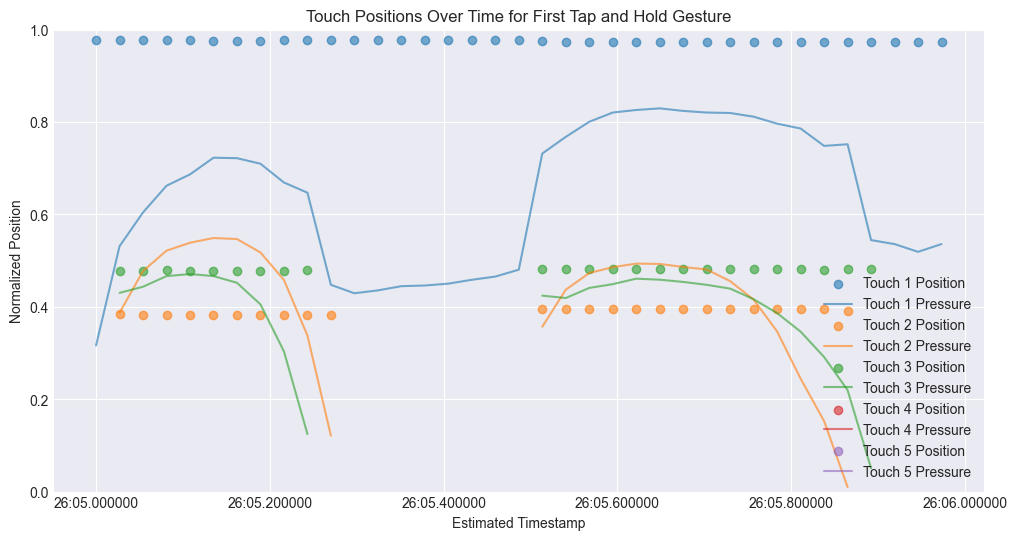

In [58]:
# Get the second "Tap and Hold" gesture group_id
first_tap_and_hold_group_id = df_clean[df_clean[LABEL_COLUMN] == 'Two-Finger Double Tap']['group_id'].iloc[0]

# Draw a graph of all touch positions for that group_id
tap_and_hold_data = df_clean[df_clean['group_id'] == first_tap_and_hold_group_id]
plt.figure(figsize=(12, 6))
for i in range(MAX_TOUCHES):
    pos_col = f'touch_{i+1}_position'
    plt.scatter(
        tap_and_hold_data['estimated_timestamp'], 
        tap_and_hold_data[pos_col], 
        label=f'Touch {i+1} Position', 
        alpha=0.6
    )
    # Draw a line for the touch pressures
    press_col = f'touch_{i+1}_pressure'
    plt.plot(
        tap_and_hold_data['estimated_timestamp'], 
        tap_and_hold_data[press_col],
        label=f'Touch {i+1} Pressure', 
        alpha=0.6
    )

plt.xlabel('Estimated Timestamp')
plt.ylabel('Normalized Position')
plt.title('Touch Positions Over Time for First Tap and Hold Gesture')
plt.ylim(0, 1)
plt.legend()
plt.show()